# Simulation of 4-Component Cat State Generation and Its GKP-Like Structure

This notebook studies **conditional optical state preparation** with the MrMustard simulator.
We model linear-optical circuits with squeezed-vacuum inputs, beam splitters, and photon-number heralding to generate non-Gaussian output states.

The motivation is twofold:
- test a numerically accessible route to 4-component optical cat-state generation [1], and
- quantify how closely the generated states resemble GKP grids using nonlinear GKP squeezing ideas [2].

## What Is Done in This Notebook

1. Validate the basic heralding mechanism on a 2-component cat construction.
2. Generate a 4-component cat candidate for fixed detector outcomes and evaluate heralding probability.
3. Sweep input squeezing to compare two operating points:
   - maximum heralding probability,
   - a more balanced Fock-space composition criterion.
4. Compute and compare Wigner functions of the selected 4-cat candidate and a rotated finite-energy GKP reference.
5. Scan lattice scaling and evaluate the nonlinear GKP-squeezing objective to identify a best-matching grid scale.
6. Perform consistency checks of the scaling scan on synthetic finite-energy GKP states.

## Scope

This is a **simulation study** intended for reproducible exploration and parameter screening.
It does not include experimental imperfections (loss, detector dark counts, mode mismatch) and therefore should be interpreted as an idealized baseline.

## References

[1] J. Hastrup, J. S. Neergaard-Nielsen, and U. L. Andersen, "Deterministic generation of a four-component optical cat state," *Optics Letters* **45**(3), 640-643 (2020). https://doi.org/10.1364/OL.383194

[2] P. Marek, "Ground State Nature and Nonlinear Squeezing of Gottesman-Kitaev-Preskill States," *Physical Review Letters* **132**, 210601 (2024). https://doi.org/10.1103/PhysRevLett.132.210601

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mrmustard.physics.wigner import wigner_discretized

from circuits_mrmustard import show_state_wigner, circuit_2cat, circuit_4cat_4modes, circuit_4cat_3modes, compare_Wigners, show_pPNRD_probabilities

#from IPython.display import display

from GKP_States import GKPState
from Gaussian_Gates_Symplectic import *

# For states generated with mrmustard use:
# display(state,...) in Jupyter for interactive plots
# show_state_wigner(state,...) for static plots that work on GitHub

# Grid for plotting Wigner functions
q_min, q_max = -5, 5
N_points = 501

## 1) Sanity check: 2-component heralded cat generation

We first validate the basic heralding mechanism in the simpler two-mode setting:

1. Two squeezed-vacuum inputs (squeezing in orthogonal quadratures)
2. One beam splitter interaction
3. Photon-number conditioning on one output mode

Conditioning on detector outcome $n$ prepares a non-Gaussian cat-like state in the remaining mode.
This step serves as a baseline check before moving to the 4-component construction.

Parameters used below:
- Input squeezing: $r_0 = 10$ dB
- Heralding outcome: $n = 2$
- Fock cutoff: 20

In [2]:
cat2, prob2 = circuit_2cat(r0 = 10, r_in_dB = True, n = 2, cutoff = 20)
display(cat2)

# Loss
eta_PD, eta_out = 0.9, 0.75

cat2_pseudo, prob2_pseudo = circuit_2cat(r0 = 10, r_in_dB = True, n = 2, cutoff = 20, eta_out=eta_out, eta_PD=eta_PD, pPNRD=True, M=28, tol_pPNRD=1e-30)
display(cat2_pseudo)
#show_state_wigner(cat2, title="2-cat state (GitHub-safe static plot)")
print("Probability of success for 2-cat state:", prob2)

Probability of success for 2-cat state: 0.106627356749868


## 2) 4-component cat candidate at fixed settings

We next generate a 4-component cat candidate with the linear-optical circuit of Ref. [1] and inspect its heralding probability and state structure.

Settings for the cell below:
- Detector outcomes: $n_1 = n_2 = 2$
- Symmetric squeezing: $r_0 = r_2 = 5$ dB
- Fock cutoff: 20

The resulting Wigner distribution is expected to show a grid-like multi-peak pattern, motivating comparison to finite-energy GKP lattices.

In [ ]:
r_dB = 3
# Loss
eta_PD, eta_out = 0.9, 0.75


cat4_old, prob4_old = circuit_4cat_4modes(r0 = r_dB, Ns = [2, 2], r2 = r_dB, r_in_dB = True, cutoff = 20)
cat4, prob4 = circuit_4cat_3modes(Ns = [2, 2], r_in = r_dB, r_in_dB = True, cutoff = 20, eta_out=eta_out, eta_PD=eta_PD, pPNRD=True, M=28, tol_pPNRD=1e-30)

print(f"r0 = r2 = {r_dB} dB")
print("Ns = [2, 2]")
print("Probability of success for 4-cat state:", prob4)
display(cat4)
#show_state_wigner(cat4, title="4-cat state (GitHub-safe static plot)")


## 2.1) Squeezing sweep and operating-point selection

We scan the input squeezing $r$ for the symmetric setting ($r=r_0=r_2$) with fixed heralding outcomes $[n_1, n_2]=[2,2]$.

### A) Maximize heralding probability
The coarse sweep identifies the squeezing that maximizes success probability.
The peak is near $r \approx 9.82$ dB with $p \approx 0.56\%$.

At this operating point, the Wigner function shows weaker lattice-like peak contrast than lower-squeezing candidates.

### B) Select a balanced Fock composition
A fine sweep selects the state minimizing $|\rho_{00}-\rho_{44}|$.
We use this balanced-population heuristic because it correlates with clearer grid-like structure in phase space.

The selected point is near $r \approx 2.7888$ dB with markedly lower heralding probability.

The printed values in the output cells below are the run-specific numbers.

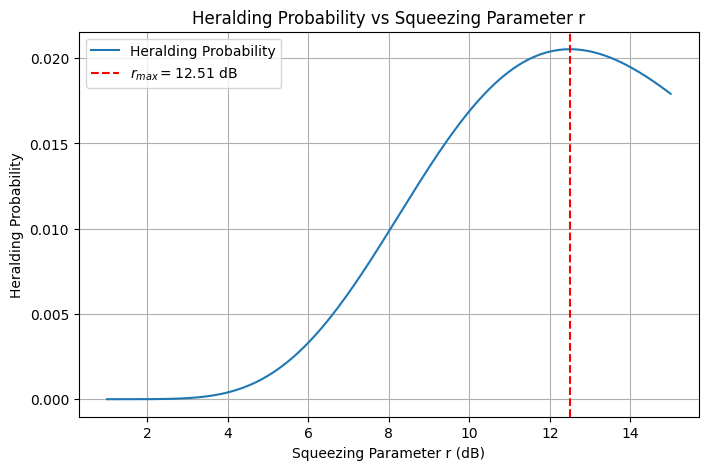

State with maximum heralding probability
r0 = r2 = 12.508000000000001 dB
Ns = [2, 2]
Maximum Probability = 0.020529900546640004


In [4]:
use_pPNRD = False # if True takes long time

# Coarse sweep: maximize heralding probability for the 4-cat construction
rs_dB = np.linspace(1, 15, 501)
max_prob = 0
best_r_dB = None
best_state = None

# Try to find functional dependence of probability on r_dB
probs = []
for r_dB in rs_dB:
    
    state, prob = circuit_4cat_3modes(r_in=r_dB, Ns=[2, 2], r_in_dB=True, cutoff=20, pPNRD=use_pPNRD, M=28, tol_pPNRD=1e-30)
    
    probs.append(prob)
    if prob > max_prob and prob < 1:
        max_prob = prob
        best_r_dB = r_dB
        best_state = state

# Plot probability vs r_dB
plt.figure(figsize=(8, 5))
plt.plot(rs_dB, probs, label="Heralding Probability")
plt.xlabel("Squeezing Parameter r (dB)")
plt.ylabel("Heralding Probability")
plt.title("Heralding Probability vs Squeezing Parameter r")
plt.axvline(x=best_r_dB, color="r", linestyle="--", label=f"$r_{{max}}={best_r_dB:.2f}$ dB")
plt.legend()
plt.grid()
plt.show()

print(f'State with maximum heralding probability')
print(f"r0 = r2 = {best_r_dB} dB")
print("Ns = [2, 2]")
print(f"Maximum Probability = {max_prob}")
display(best_state)
#show_state_wigner(best_state, title="Best-probability 4-cat state (GitHub-safe static plot)")

In [ ]:
use_pPNRD = True # if True takes long time

# Fine sweep: select the most balanced state via |rho_00 - rho_44|
rs_dB = np.linspace(2.76, 2.8, 21)
balanced_r_dB = None
balanced_state = None
balanced_prob = None

for r_dB in rs_dB:
    state, prob = circuit_4cat_3modes(
        r_in=r_dB, Ns=[2, 2], r_in_dB=True, cutoff=20, pPNRD=use_pPNRD, M=28, tol_pPNRD=1e-30
    )
    cutoff = 5
    rho = state.dm().fock_array(shape=cutoff)

    if balanced_state is None:
        balanced_state = state
        balanced_r_dB = r_dB
        balanced_prob = prob
    else:
        rho_balanced = balanced_state.dm().fock_array(shape=cutoff)
        if abs(rho[0, 0] - rho[4, 4]) < abs(rho_balanced[0, 0] - rho_balanced[4, 4]):
            balanced_state = state
            balanced_r_dB = r_dB
            balanced_prob = prob

balanced_Wig, X, P = wigner_discretized(
    balanced_state.dm().ansatz.array, np.linspace(-5, 5, 200), np.linspace(-5, 5, 200)
)

print(
    f"Balanced state with minimal |rho_00 - rho_44| obtained at r0 = r2 = {balanced_r_dB} dB"
)
print("Ns = [2, 2]")
print(f"Probability of selected balanced state = {balanced_prob}")

display(balanced_state)
#show_state_wigner(balanced_state, title="Balanced 4-cat state (GitHub-safe static plot)")

## 3) GKP interpretation and scale fitting

This section tests how well the selected balanced 4-cat state can be interpreted as a **rotated finite-energy GKP-like state** with a rescaled lattice constant [2].

### Why this comparison is useful
The 4-cat Wigner function shows a grid-like interference structure.  
A quantitative way to test this resemblance is to evaluate the nonlinear GKP-squeezing objective $\xi(s)$ [2] and find the lattice scale that minimizes it.

### Criterion quantifying GKP-ness (for a given grid) of the state
For lattice vectors $v_1,v_2$, displacement $d$, and scale $l$, define
$$
\mathit{Q}_{l,v_1,v_2,d}(\hat r)=2-\cos\!\left(\tfrac{1}{2}l\,[\omega(\hat r,v_1)+\omega(d,v_1)]\right)-\cos\!\left(l\,[\omega(\hat r,v_2)+\omega(d,v_2)]\right),
$$
with symplectic form $\omega(x,y)=x^T\Omega y$.

The nonlinear GKP-squeezing for this grid is defined as
$$
\xi_{l,v_1,v_2,d}=\langle\mathit{Q}_{l,v_1,v_2,d}(\hat r)\rangle,
$$
where smaller values indicate better consistency with the chosen grid.

### GKP state resembling the cat state
For comparison we consider the $\pi/4$-rotated $|0\rangle_{\mathrm{L}}$ GKP state, with
$$
v_1=\frac{1}{\sqrt2}(1,1)^T,\qquad v_2=\frac{1}{\sqrt2}(1,-1)^T,\qquad d=(0,0)^T.
$$
Its canonical qubit lattice scale is
$$
l_{\mathrm{qubit}}=2\sqrt{\pi}.
$$
We fit a dimensionless scaling parameter $s$ such that
$$
l=s\,l_{\mathrm{qubit}},
$$
and equivalently evaluate
$$
\mathit{Q}^{(s)}(\hat x,\hat p)=2-\cos\!\left(s\sqrt{2\pi}(\hat x-\hat p)\right)-\cos\!\left(s\sqrt{2\pi}(\hat x+\hat p)\right).
$$

### What the next code cells do
1. Compute Wigner functions for the balanced 4-cat state and the rotated finite-energy GKP reference on the same phase-space grid.
2. Compare both Wigner functions visually using shared color scaling.
3. Scan $s$ (via `compare_scaled_grid`) and locate nontrivial local minima of $\xi(s)$.
4. Use the best physically meaningful minimum to set the effective lattice scale and overlay lattice points.

### Reproducibility note on width parameters
The visual comparison uses `delta = 0.4` in the displayed finite-energy GKP Wigner function.
The scale scan uses `delta_fixed = 0.1` to probe sharper lattice features in the fitting objective.
Using different values is intentional.

### Interpretation note
Because $\xi(s)$ is oscillatory and has a trivial small-$s$ limit, scale selection should combine the objective minimum with visual lattice-peak consistency, not objective value alone.

Q-operator for this GKP reference state:
Grid with: scaling s=1, l=3.5449077018110318, v1=(0.7071067811865475, 0.7071067811865476)^T, v2=(0.7071067811865476, -0.7071067811865475)^T, displacement=(0.0, 0.0)
Q^{(s)}_{l,v_1,v_2,d} = 2 - cos(1/2 *1*3.5449077018110318*[x*(0.7071067811865476) - p*(0.7071067811865475) +phi_1]) - cos( 1*3.5449077018110318*[x*(-0.7071067811865475) - p*(0.7071067811865476) + phi_2])
phi1 = 0.0
phi2 = -0.0


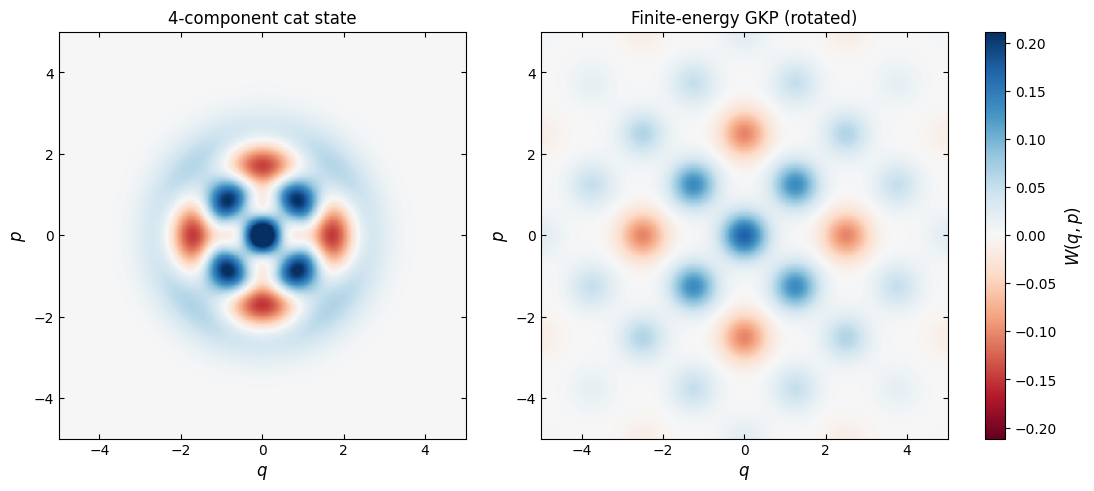

In [ ]:
# Build target and reference Wigner functions on common grid
Wigner_4cat = wigner_discretized(
    balanced_state.dm().ansatz.array,
    np.linspace(q_min, q_max, N_points),
    np.linspace(q_min, q_max, N_points),
)

delta = 0.4
GKP_approx = GKPState.computational_GKP(0).apply_gaussian_gate(Phase_rotation(np.pi / 4))
Wigner_GKP = GKP_approx.wigner_finite_energy(
    delta_x=delta, x_range=(q_min, q_max), p_range=(q_min, q_max), num_points=N_points
)

print("Q-operator for this GKP reference state:")
GKP_approx.Q_operator(print_Q=True)

compare_Wigners(
    Wigner_4cat,
    Wigner_GKP,
    title1="4-component cat state",
    title2="Finite-energy GKP (rotated)",
    common_scale=True,
    shared_colorbar=True,
    percentile=99.7,
    dpi=400,
)

Best scaling s: 0.669400
Best xi:  1.099
Candidate minima:
   1) s=0.669400, xi=1.099
   2) s=1.379200, xi=1.131
   3) s=2.752000, xi=1.806


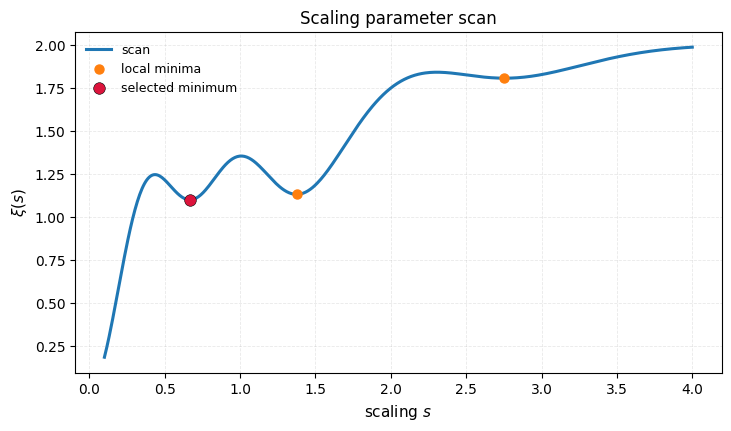

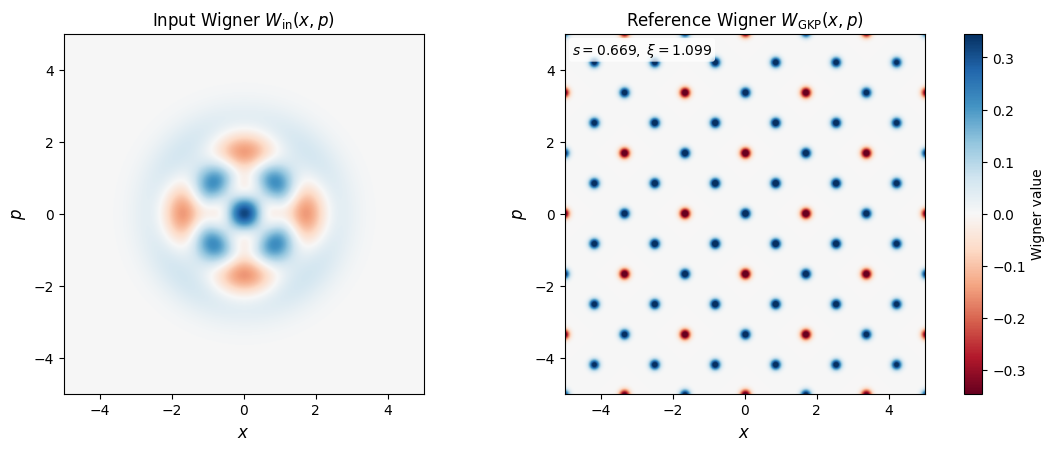

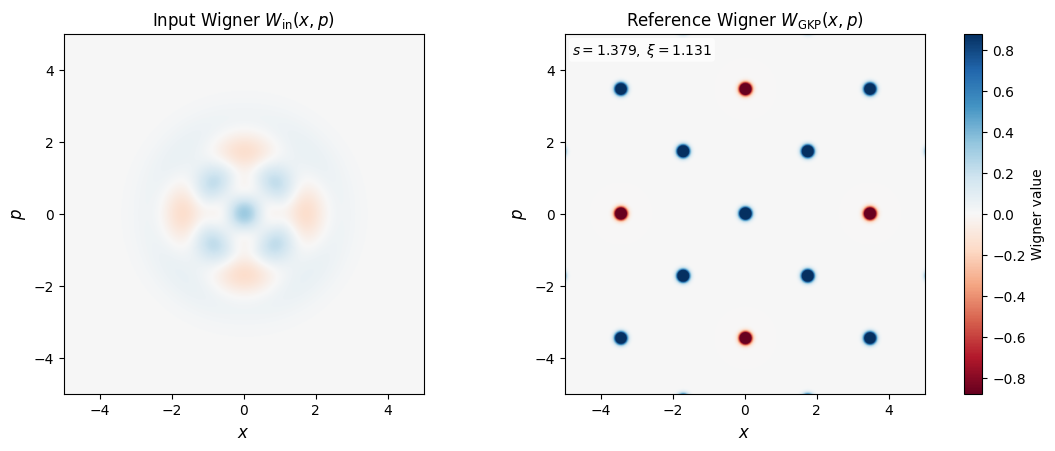

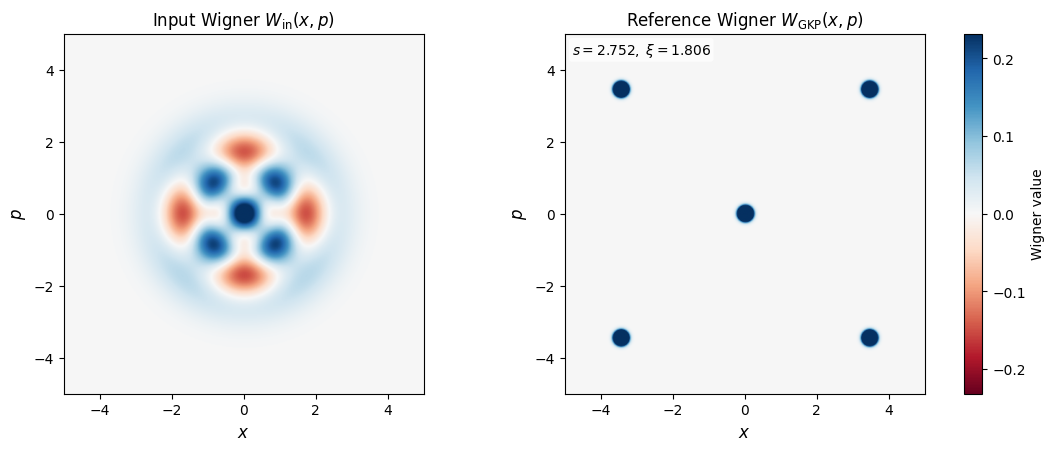

In [ ]:
Fit_4cat_balanced = GKP_approx.compare_scaled_grid(
    Wigner_4cat, 0.1, 4, num_points=501, normalized_xi=False, delta_fixed=0.1
)

## 3.1) Observations from the scale scan

The objective $\xi(s)$ exhibits multiple local minima.

Key points:
- As $s\to 0$, $\xi(s)\to 0$ due to the cosine expansion; this is a **trivial** limit and not a useful physical fit.
- The first nontrivial local minimum (here near $s_{\mathrm{opt}}\approx 0.6694$) gives the best practical grid match.
- Additional minima appear at related scales, so selecting the physically relevant branch requires visual and contextual checks.

### Results

Using the selected nontrivial minimum, the balanced 4-cat state is best matched by a rotated logical $|0\rangle_\mathrm{GKP}$ with effective lattice scale
$$
l_{\mathrm{opt}} = s_{\mathrm{opt}} \times l_{\mathrm{qubit}} \approx 2.372961 \; (= 0.6694\times 2\sqrt{\pi}).
$$

A small residual scale bias may remain because broad finite-energy peaks and the bounded cosine objective can slightly shift the estimated optimum.

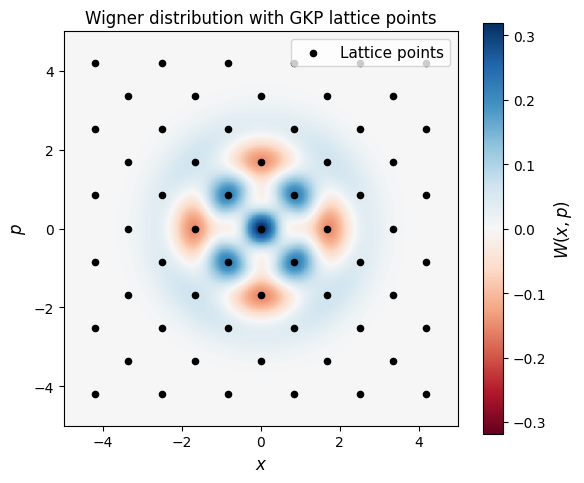

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Wigner distribution with GKP lattice points'}, xlabel='$x$', ylabel='$p$'>)

In [ ]:
scaling = 2.372961  # = 0.669400 * 2 * sqrt(pi)
# Keep as a placeholder (set to 1.0) unless an explicit bias-correction method is introduced.
bias_factor = 1.0
correct_grid = GKP_approx
correct_grid.l = scaling * bias_factor

# correct_grid.plot_wigner_finite_energy(scale_axes_by_l=False)
# Wigner_grid = correct_grid.wigner_finite_energy(delta_x=0.35, x_range=(q_min, q_max), p_range=(q_min, q_max), num_points=N_points, normalize=True)
# compare_Wigners(Wigner_4cat, Wigner_grid, title1="4-component cat state", title2=f"Scaled GKP grid (l={scaling:.3f})", common_scale=True, shared_colorbar=True, percentile=99.7, dpi=400)

correct_grid.show_lattice_points(Wigner_4cat, show_plot=True, all_points=True)

## 4) Consistency check: $\xi$ versus scale on synthetic GKP data

We repeat the same scale scan on synthetic rotated finite-energy GKP states with different envelope widths to understand bias and multimodality.

Main observations:
- As $s\to 0$, $\xi(s)\to 0$ because the cosine terms approach 1 (trivial small-scale limit).
- For narrow envelopes ($\delta_x=\delta_p$ small), $\xi(s)$ is strongly oscillatory, with minima separated by approximately $\Delta s\approx 1/2$.
- For broader envelopes, oscillations are damped and the inferred optimum can shift slightly to smaller scales.

This check supports using both objective-value minima and phase-space structure when selecting the final scale.

Best scaling s: 1.001600
Best xi:  0.103
Candidate minima:
   1) s=0.511600, xi=1.039
   2) s=1.001600, xi=0.103
   3) s=1.521000, xi=1.140
   4) s=2.001200, xi=0.284
   5) s=2.530400, xi=1.310
   6) s=3.010600, xi=0.587
   7) s=3.559400, xi=1.495
   8) s=3.990600, xi=0.855
   9) s=4.568800, xi=1.669


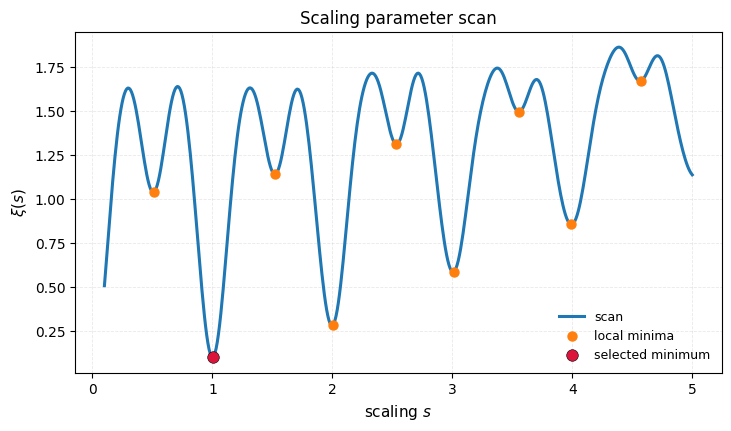

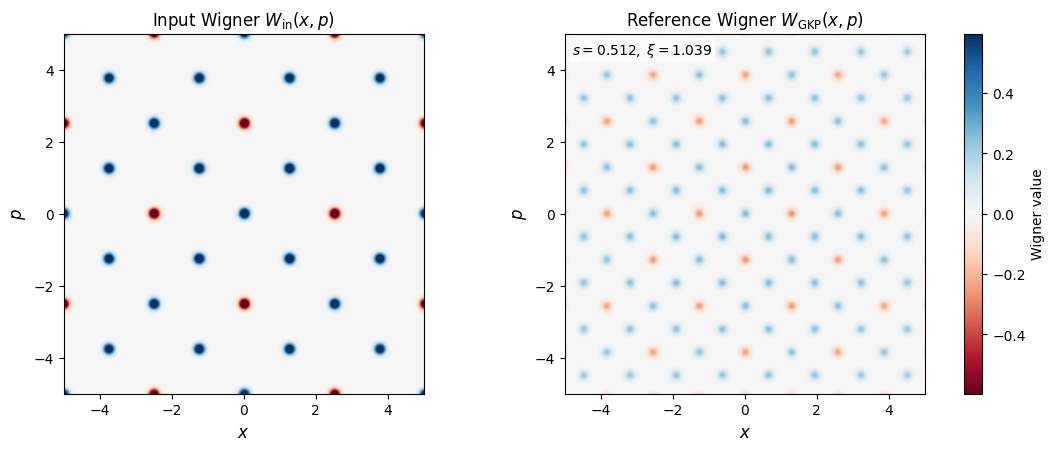

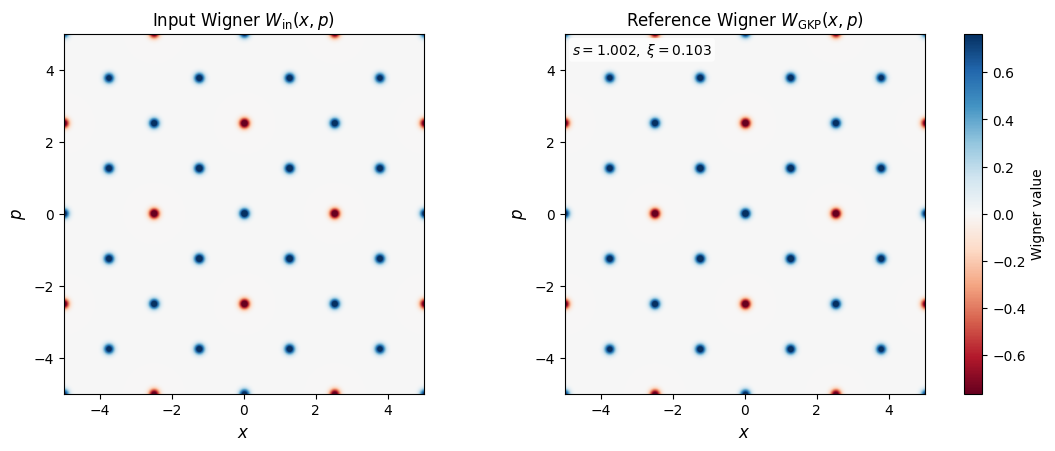

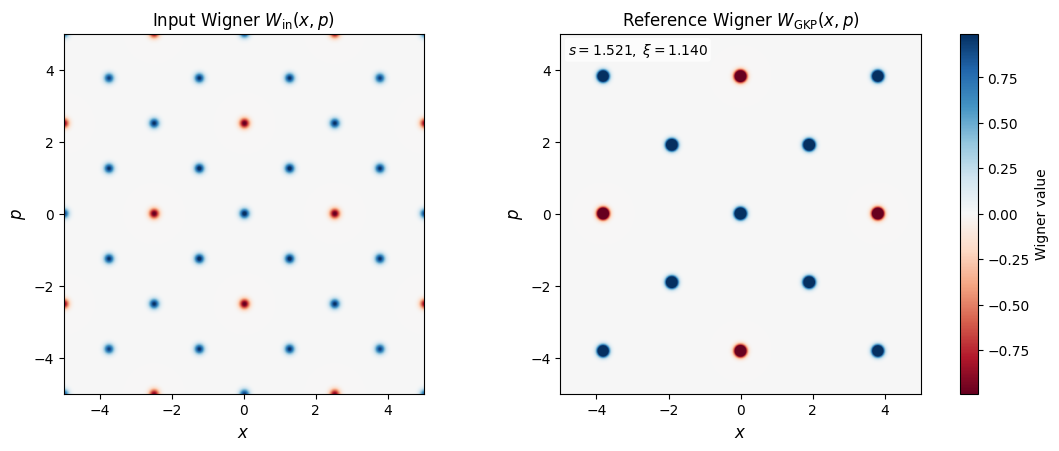

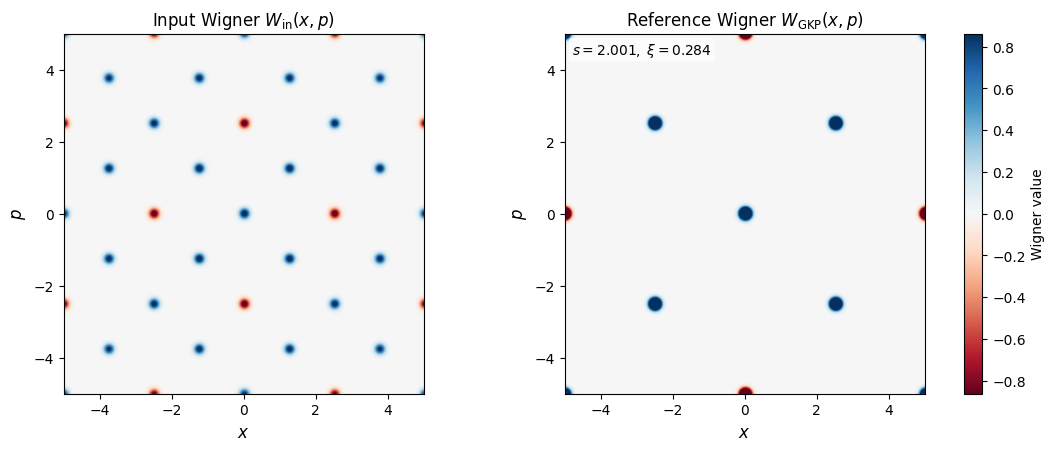

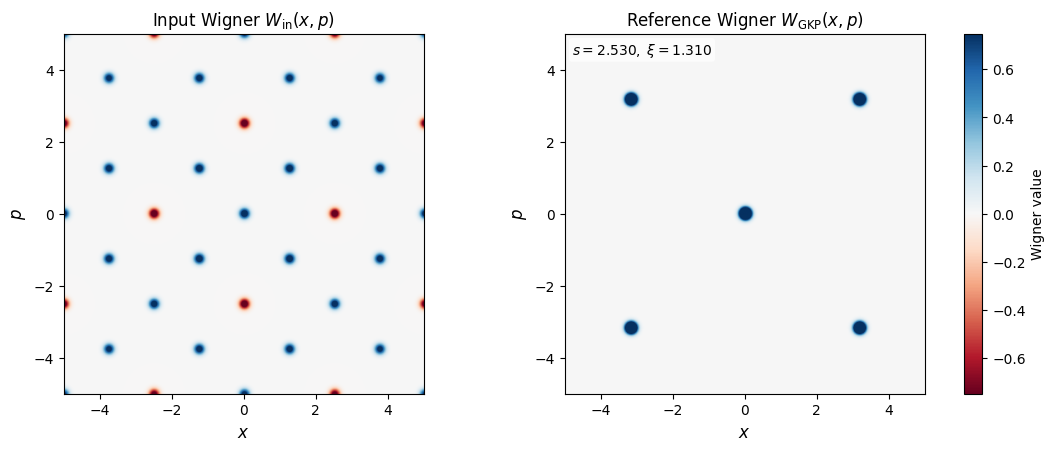

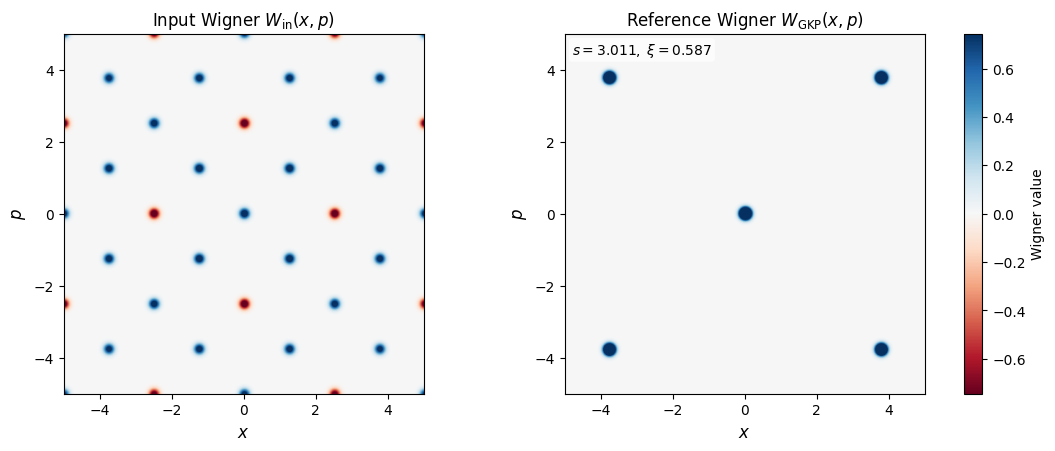

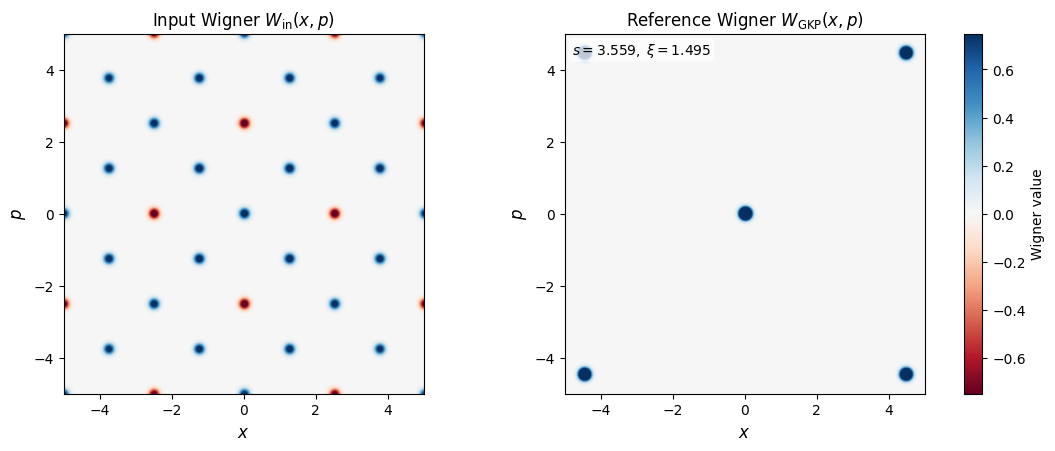

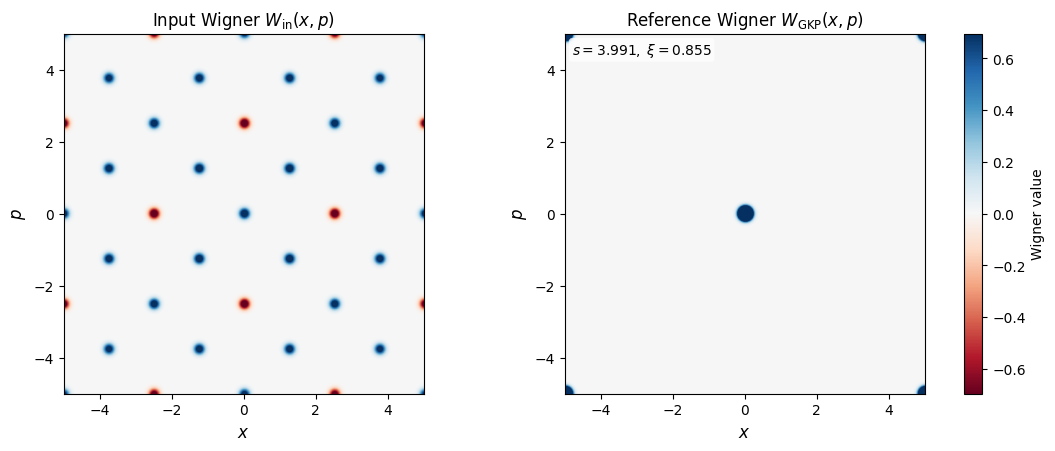

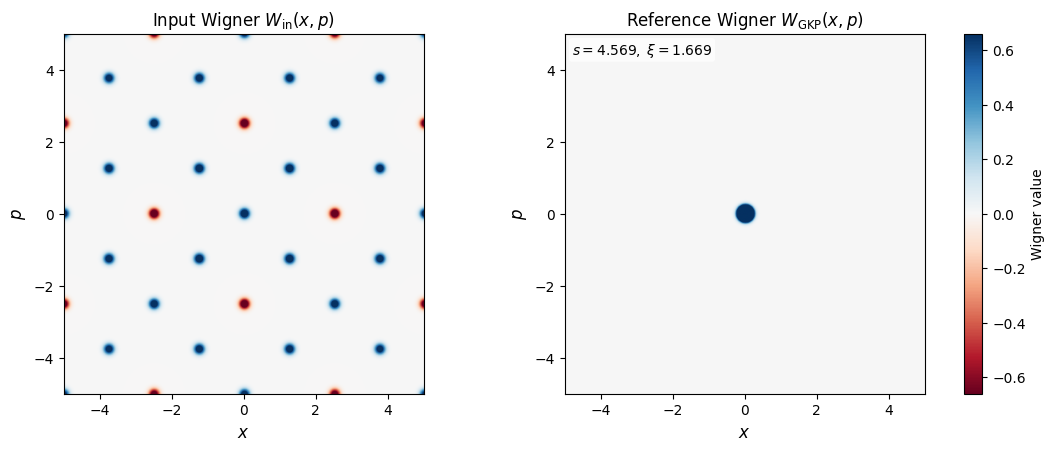

In [ ]:
# Controlled checks: same state family with different finite-energy widths
GKP_test = GKPState.computational_GKP(0).apply_gaussian_gate(Phase_rotation(np.pi / 4))
Wigner_check_1 = GKP_test.wigner_finite_energy(
    delta_x=0.1, x_range=(q_min, q_max), p_range=(q_min, q_max), num_points=N_points
)
Wigner_check_5 = GKP_test.wigner_finite_energy(
    delta_x=0.5, x_range=(q_min, q_max), p_range=(q_min, q_max), num_points=N_points
)

# GKP_test.show_lattice_points(Wigner_check_1, show_plot=True, all_points=True)

Fit_check_1 = GKP_test.compare_scaled_grid(
    Wigner_check_1, 0.1, 5, num_points=501, normalized_xi=False, delta_fixed=0.1, #max_candidates=5
)


Best scaling s: 0.442200
Best xi:  0.914
Candidate minima:
   1) s=0.442200, xi=0.914
   2) s=0.935200, xi=1.103
   3) s=1.869000, xi=1.766
   4) s=2.802800, xi=1.968


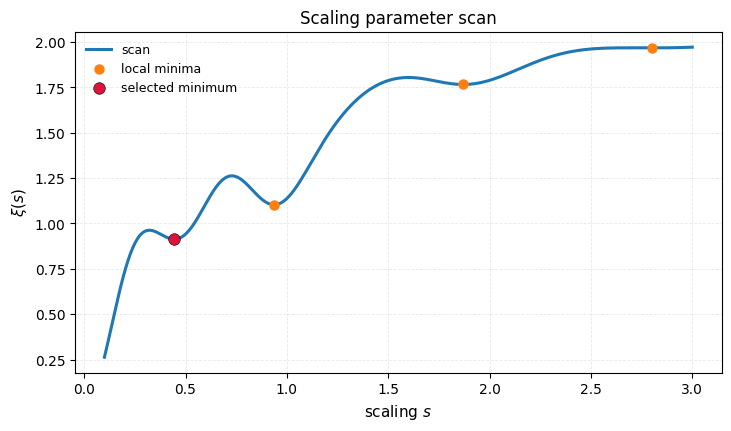

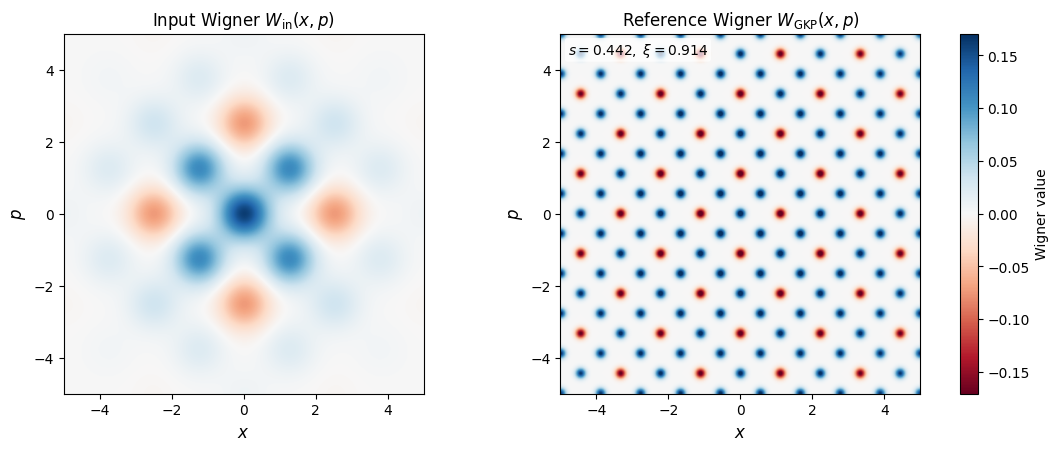

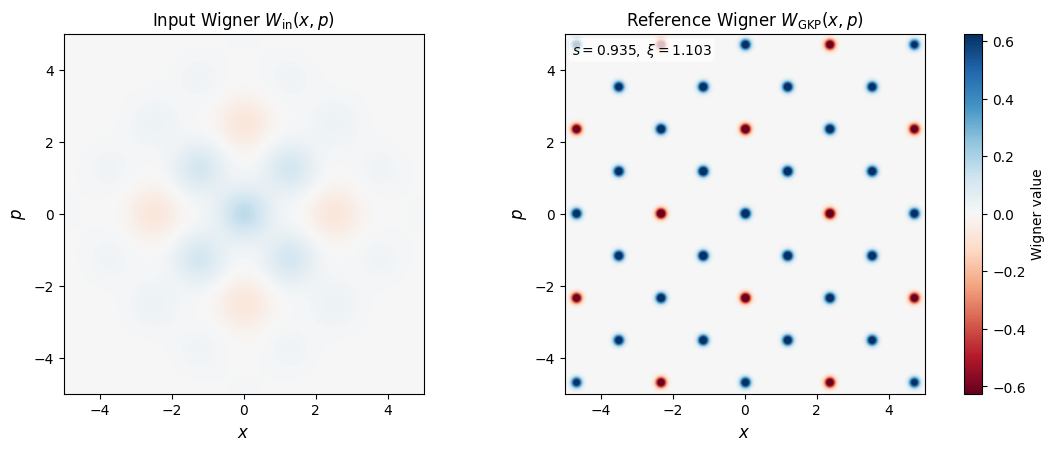

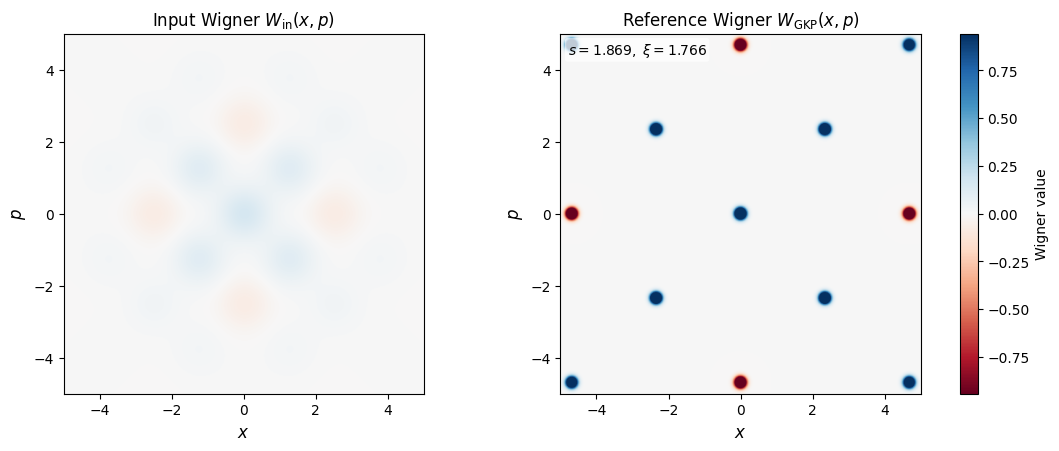

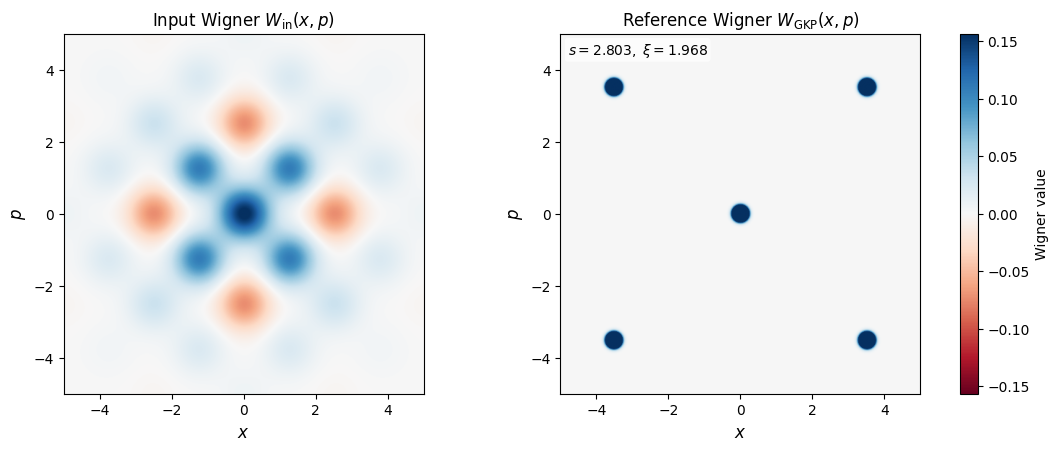

In [ ]:
Fit_check_5 = GKP_test.compare_scaled_grid(
    Wigner_check_5, 0.1, 3, num_points=501, normalized_xi=False, delta_fixed=0.1
)

In [ ]:
# Compact run-summary for reporting/reproducibility
summary = {
    "r_max_dB": float(best_r_dB),
    "p_max": float(max_prob),
    "r_balanced_dB": float(balanced_r_dB),
    "p_balanced": float(balanced_prob),
}

if "scaling" in globals():
    summary["l_eff"] = float(scaling)
    summary["s_opt"] = float(scaling / (2 * np.sqrt(np.pi)))

print("Key numerical results (current run):")
for key, value in summary.items():
    print(f"- {key}: {value}")

Key numerical results (current run):
- r_max_dB: 9.82
- p_max: 0.005593936574372055
- r_balanced_dB: 2.7887999999999997
- p_balanced: 3.524982989241026e-05
- l_eff: 2.372961
- s_opt: 0.6693999391825337


## 5) Conclusions

- The linear-optical heralding circuit produces 4-component cat candidates with grid-like phase-space structure.
- There is a trade-off between heralding probability and the chosen state-quality heuristic ($|\rho_{00}-\rho_{44}|$).
- In the regime with significant contributions of $\rho_{00}$ and $\rho_{44}$, the cat state is well described by a rotated finite-energy GKP reference with a nontrivial rescaled lattice constant.
- Scale fitting via nonlinear GKP squeezing is informative but multimodal; physically meaningful minima should be selected using both objective values and Wigner-structure consistency.

These results provide an idealized baseline for future studies including loss, detector imperfections, and mode mismatch.